# Image Class

In [1]:
import cv_depot.api as cvd

<font size=4 color="#EBB483"><br>Image instance dispay ImageViewer's per default in notebooks

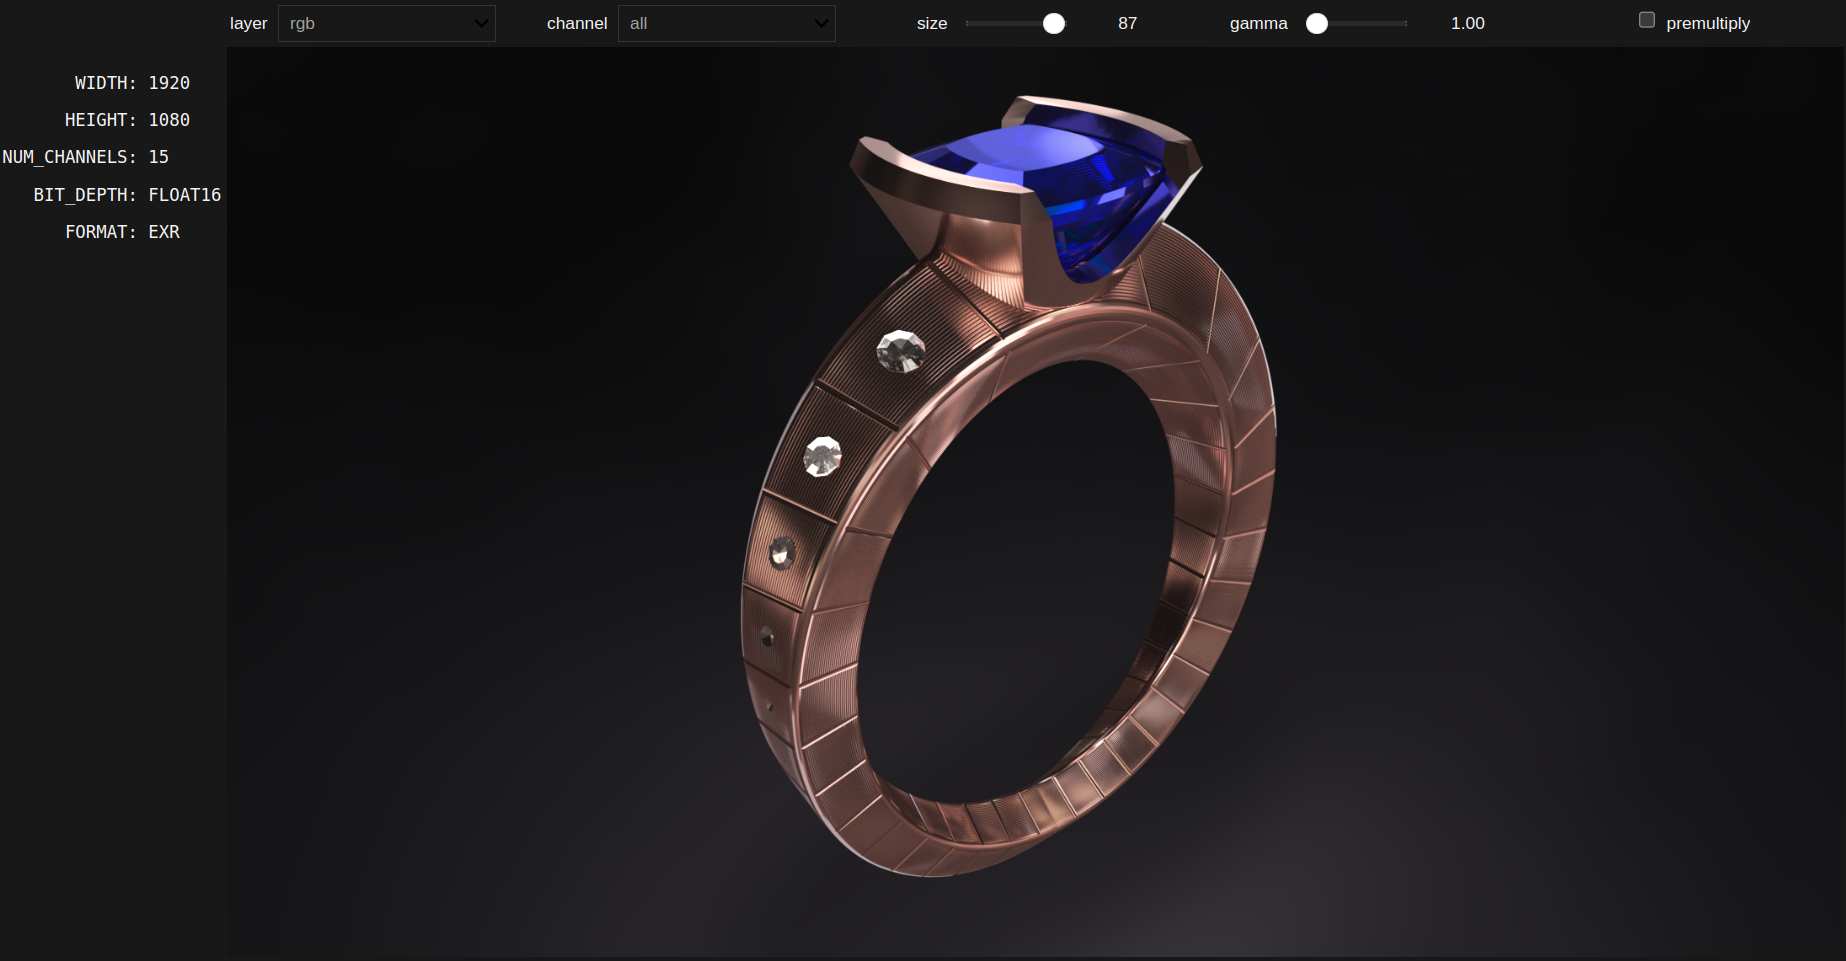

In [5]:
src = '/home/ubuntu/images/misc/p-ring_s-rndr001_d-demo_v001_f0300.exr'
image = cvd.Image.read(src)
image

<font size=4 color="#EBB483"><br>ImageViewers allow you to interactively adjust their layer, channel, display size and display gamma.

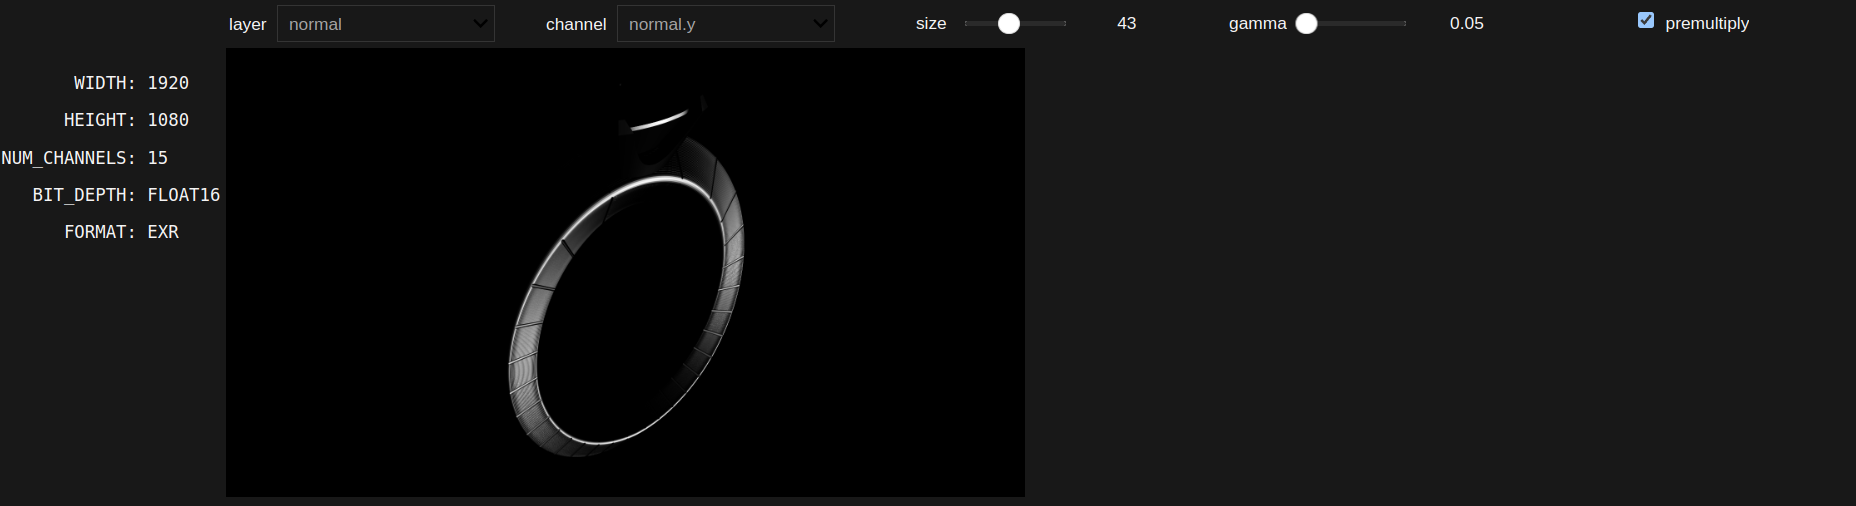

In [6]:
image

---
# Special Methods

<font size=4 color="#EBB483"><br>**\__getitem__** is used to crop the image and select layers or single channels.

<font size=4 color="#EBB483"><br>For instace, *position* or *position.x* are legal values.

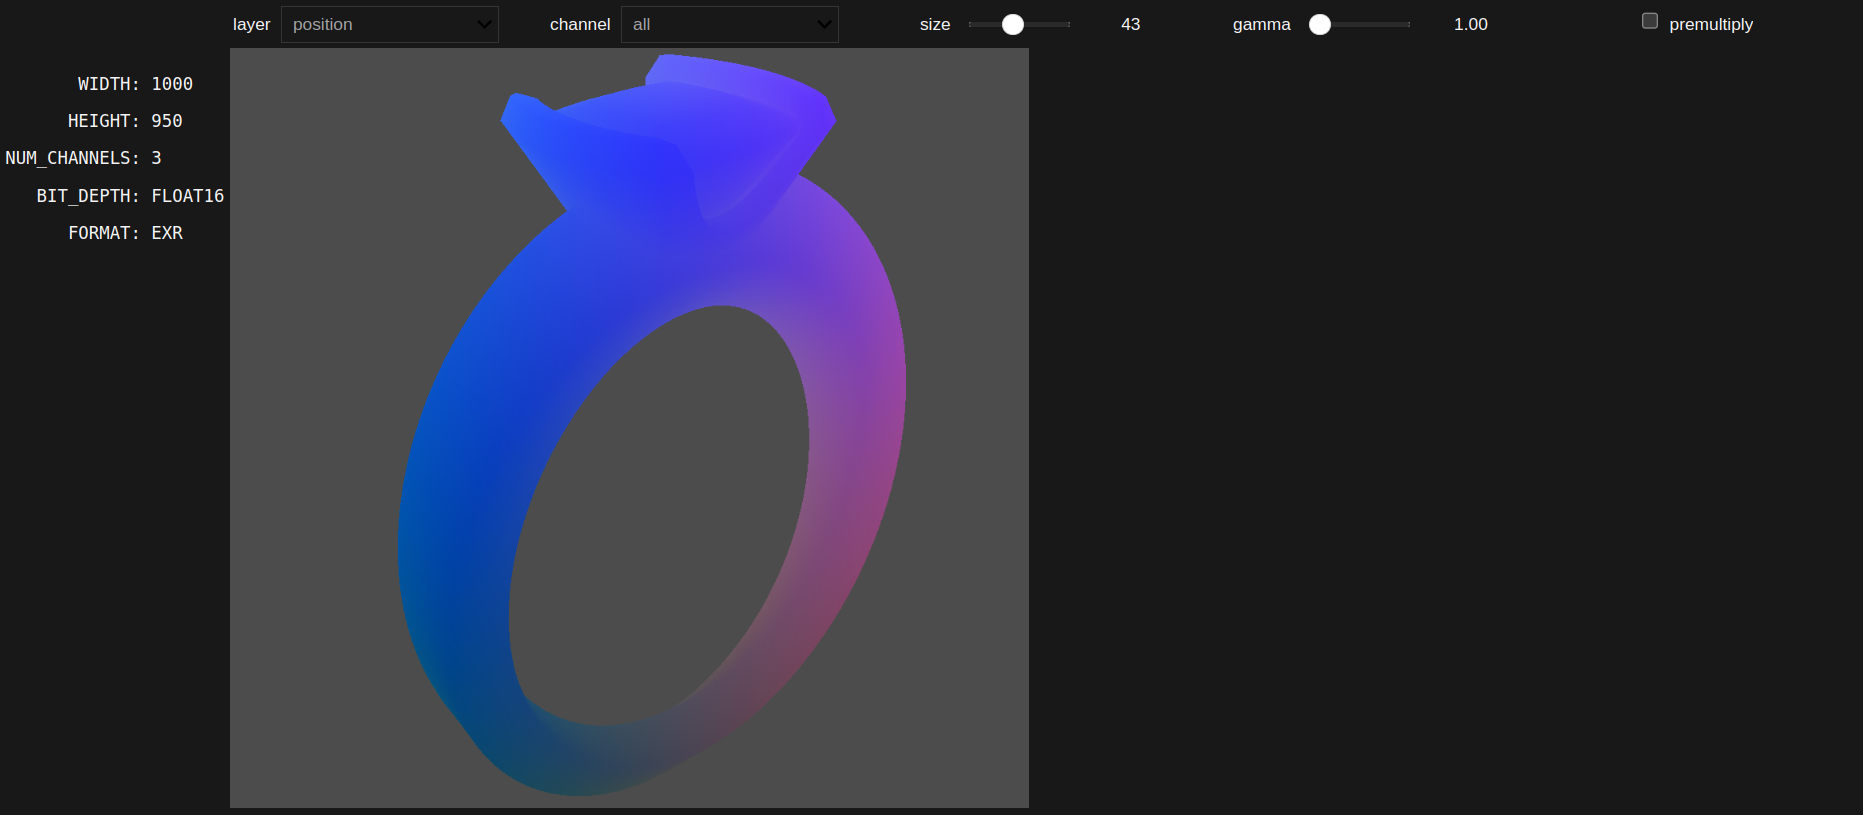

In [7]:
#    left:right  top:bottom  layer or channel
image[400:1400,  50:1000,    'position'      ]

<font size=4 color="#EBB483"><br>**set_channels** sets the Image channels to a given list. In general, it is recommended you follow the *layer.channel* name scheme.

In [20]:
rgb = image[:, :, 'rgb']
abc = rgb.set_channels(['some_layer.a', 'some_layer.b', 'some_layer.c'])
abc.channels

['some_layer.a', 'some_layer.b', 'some_layer.c']

<font size=4 color="#EBB483"><br>**compare** returns a dictionary of comparisons between source and target image properties.

In [14]:
beauty = image.read('/home/ubuntu/images/misc/p-ring_s-rndr001_d-beauty_v002_f0204.exr')
image.compare(beauty)

{'width': (1920, 1920),
 'height': (1080, 1080),
 'channels': (['r',
   'g',
   'b',
   'ao.blue',
   'ao.green',
   'ao.red',
   'normal.x',
   'normal.y',
   'normal.z',
   'position.x',
   'position.y',
   'position.z'],
  ['r', 'g', 'b']),
 'num_channels': (12, 3),
 'bit_depth': ('FLOAT16', 'FLOAT16'),
 'dtype': (numpy.float16, numpy.float16),
 'bits': (16, 16),
 'signed': (True, True),
 'type': (float, float),
 'format_extension': ('exr', 'exr'),
 'format_bit_depths': ([BitDepth.FLOAT16, BitDepth.FLOAT32],
  [BitDepth.FLOAT16, BitDepth.FLOAT32]),
 'format_channels': (['r', 'g', 'b', 'a', '...'], ['r', 'g', 'b', 'a', '...']),
 'format_max_channels': (1023, 1023),
 'format_custom_metadata': (True, True)}

<font size=4 color="#EBB483"><br>**diff_only** will display only the differences.

In [17]:
image.compare(beauty, diff_only=True)

{'channels': (['r',
   'g',
   'b',
   'ao.blue',
   'ao.green',
   'ao.red',
   'normal.x',
   'normal.y',
   'normal.z',
   'position.x',
   'position.y',
   'position.z'],
  ['r', 'g', 'b']),
 'num_channels': (12, 3)}

<font size=4 color="#EBB483"><br>**content** will difference the image content.

In [18]:
rgb = image[:, :, 'rgb']
rgb.compare(beauty, content=True, diff_only=True)

{'mean_content_difference': 0.095703125}

---
# Properties

<font size=4 color="#EBB483"><br>**info** returns aggregated image information

In [79]:
from pprint import pprint
pprint(image.info)

{'bit_depth': 'FLOAT16',
 'bits': 16,
 'channels': ['r',
              'g',
              'b',
              'ao.blue',
              'ao.green',
              'ao.red',
              'normal.x',
              'normal.y',
              'normal.z',
              'position.x',
              'position.y',
              'position.z'],
 'dtype': <class 'numpy.float16'>,
 'format_bit_depths': [BitDepth.FLOAT16, BitDepth.FLOAT32],
 'format_channels': ['r', 'g', 'b', 'a', '...'],
 'format_custom_metadata': True,
 'format_extension': 'exr',
 'format_max_channels': 1023,
 'height': 1080,
 'num_channels': 12,
 'signed': True,
 'type': <class 'float'>,
 'width': 1920}


<font size=4 color="#EBB483"><br>Channel Properties

In [57]:
print('channel_layers:', image.channel_layers)
print('      channels:', image.channels)

channel_layers: ['rgb', 'ao', 'normal', 'position']
      channels: ['r', 'g', 'b', 'ao.blue', 'ao.green', 'ao.red', 'normal.x', 'normal.y', 'normal.z', 'position.x', 'position.y', 'position.z']


<font size=4 color="#EBB483"><br>**metadata** returns image format metadata (EXR format can store custom metadata).

In [80]:
pprint(image.metadata)

{'channels': ['r',
              'g',
              'b',
              'ao.blue',
              'ao.green',
              'ao.red',
              'normal.x',
              'normal.y',
              'normal.z',
              'position.x',
              'position.y',
              'position.z'],
 'compression': <ImageCodec.PIZ>
  string: piz
exr_code: 4,
 'dataWindow': (0, 0) - (1919, 1079),
 'displayWindow': (0, 0) - (1919, 1079),
 'lineOrder': INCREASING_Y,
 'nuke/full_layer_names': 0,
 'nuke/node_hash': '26609d779ce5792c',
 'nuke/version': '11.0v1',
 'num_channels': 12,
 'pixelAspectRatio': 1.0,
 'screenWindowCenter': (0.0, 0.0),
 'screenWindowWidth': 1.0,
 'type': 'scanlineimage',
 'version': 1}


<font size=4 color="#EBB483"><br>Format Properties

In [59]:
print('      format:', image.format)
print('   extension:', image.extension)
print('max_channels:', image.max_channels)
print('   bit_depth:', image.bit_depth)

      format: ImageFormat.EXR
   extension: exr
max_channels: 1023
   bit_depth: BitDepth.FLOAT16


<font size=4 color="#EBB483"><br>Shape Properties

In [60]:
print('           width:', image.width)
print('          height:', image.height)
print('width_and_height:', image.width_and_height)
print('    num_channels:', image.num_channels)
print('           shape:', image.shape)

           width: 1920
          height: 1080
width_and_height: (1920, 1080)
    num_channels: 12
           shape: (1920, 1080, 12)


---
# IO

<font size=4 color="#EBB483"><br>Image data is stored internally as a numpy array.

<font size=4 color="#EBB483"><br>**data** and **to_array** return that array.

In [82]:
image.data
array = image.to_array()
array.shape

(1080, 1920, 12)

<font size=4 color="#EBB483"><br>**read** reads an image from a filepath. EXR, PNG, JPEG and TIFF formats are supported.

In [ ]:
src = '/home/ubuntu/images/misc/p-ring_s-rndr001_d-demo_v001_f0300.exr'
image = cvd.Image.read(src)

<font size=4 color="#EBB483"><br>**from_array** reads an image from a numpy array.

In [93]:
import numpy as np
array = np.zeros((64, 64), dtype=np.uint8)
x = image.from_array(array)
x.data.shape

(64, 64)

<font size=4 color="#EBB483"><br>**from_pil** reads an image from a PIL Image.

In [94]:
import PIL.Image as pil
x = image.from_pil(pil.fromarray(array))

<font size=4 color="#EBB483"><br>**write** writes an image to a file. The format is inferred from the extension. If the format supports metadata, that will be written as well.

In [ ]:
image.write(
    '/home/ubuntu/images/misc/demo-image.exr',
    codec=cvd.ImageCodec.PIZ,
)

<font size=4 color="#EBB483"><br>**to_pil** returns a PIL Image instance.

In [85]:
pil = image[:, :, 'rgb'].to_pil()
pil.__class__

<class 'PIL.Image.Image'>

<font size=4 color="#EBB483"><br>**to_unit_space** scales each channel to fit within a 0 to 1 space.

In [91]:
unit = image.to_unit_space()
n = unit[:, :, 'position.z'].data
n.max(), n.min()

(np.float16(1.0), np.float16(0.3818))

<font size=4 color="#EBB483"><br>**to_bit_depth** converts an Image to a different bit depth. All the 0-1/0-255 math is handled.

In [92]:
x = unit.to_bit_depth(cvd.BitDepth.UINT8)
x.bit_depth

BitDepth.UINT8